In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [2]:
df = pd.read_csv('Mental_Health_Lifestyle_Dataset.csv')

Dataset clean up encode + remove nulls

In [3]:
df = df.drop('Country', axis=1)

In [7]:
df.head()

,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,48,Male,Low,Vegetarian,6.3,Low,0,21,4.0,7.8,6.5
1,31,Male,Moderate,Vegan,4.9,Low,1,48,5.2,8.2,6.8
2,37,Female,Low,Vegetarian,7.2,High,0,43,4.7,9.6,9.7
3,35,Male,Low,Vegan,7.2,Low,2,43,2.2,8.2,6.6
4,46,Male,Low,Balanced,7.3,Low,3,35,3.6,4.7,4.4


In [5]:
df['Mental Health Condition'].unique()

array([nan, 'PTSD', 'Depression', 'Anxiety', 'Bipolar'], dtype=object)

In [6]:
df['Mental Health Condition'] = df['Mental Health Condition'].replace(
    {np.nan: 0,
    None: 0,
    'PTSD': 1,
    'Depression': 2,
    'Anxiety': 3,
    'Bipolar': 4,
    }
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_16476\505613818.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Mental Health Condition'] = df['Mental Health Condition'].replace(


In [19]:
df.head()

,Age,Gender,Exercise Level,Diet Type,Sleep Hours,Stress Level,Mental Health Condition,Work Hours per Week,Screen Time per Day (Hours),Social Interaction Score,Happiness Score
0,48,0,0,0,6.3,0,0,21,4.0,7.8,6.5
1,31,0,1,1,4.9,0,1,48,5.2,8.2,6.8
2,37,1,0,0,7.2,2,0,43,4.7,9.6,9.7
3,35,0,0,1,7.2,0,2,43,2.2,8.2,6.6
4,46,0,0,2,7.3,0,3,35,3.6,4.7,4.4


In [8]:
df['Gender'] = df['Gender'].replace(
    {'Male':0,
    'Female':1,
    'Other':2}
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_16476\3136395727.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Gender'] = df['Gender'].replace(


In [10]:
df['Diet Type'].unique()

array(['Vegetarian', 'Vegan', 'Balanced', 'Junk Food', 'Keto'],
      dtype=object)

In [11]:
df['Diet Type'] = df['Diet Type'].replace({
    'Vegetarian':0,
    'Vegan':1,
    'Balanced':2,
    'Junk Food':3,
    'Keto':4
})

C:\Users\prbha\AppData\Local\Temp\ipykernel_16476\1771269512.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Diet Type'] = df['Diet Type'].replace({


In [13]:
df['Exercise Level'].unique()

array(['Low', 'Moderate', 'High'], dtype=object)

In [14]:
df['Exercise Level'] = df['Exercise Level'].replace({
    'Low':0,
    'Moderate':1,
    'High':2
})

C:\Users\prbha\AppData\Local\Temp\ipykernel_16476\3197169366.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Exercise Level'] = df['Exercise Level'].replace({


In [18]:
df['Stress Level'].unique()

array([0, 2, 1])

In [17]:
df['Stress Level'] = df['Stress Level'].replace(
    {
        'Low':0,
        'Moderate':1,
        'High':2
    }
)

C:\Users\prbha\AppData\Local\Temp\ipykernel_16476\3705384534.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Stress Level'] = df['Stress Level'].replace(


In [102]:

df.isnull().sum()

Age                            0
Gender                         0
Exercise Level                 0
Diet Type                      0
Sleep Hours                    0
Stress Level                   0
Mental Health Condition        0
Work Hours per Week            0
Screen Time per Day (Hours)    0
Social Interaction Score       0
Happiness Score                0
dtype: int64

Finding the best number of clusters

In [23]:


# ===== PREPARE DATA FOR CLUSTERING =====

# Select features for clustering (exclude any ID columns if present)
# Assuming all your columns are now features
features_for_clustering = df.columns.tolist()

# If you have an ID column or original categorical columns, exclude them:
# features_for_clustering = [col for col in df.columns if col not in ['UserID', 'Diet', 'Gender', 'MentalHealthCondition']]

print(f"Features used for clustering: {features_for_clustering}")
print(f"Number of features: {len(features_for_clustering)}")

X = df[features_for_clustering].values

# ===== SCALE FEATURES (CRITICAL FOR K-MEANS) =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"\nScaled data shape: {X_scaled.shape}")




Features used for clustering: ['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 'Stress Level', 'Mental Health Condition', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']
Number of features: 11

Scaled data shape: (3000, 11)


In [24]:
features = df.columns.tolist()

In [25]:
X = df[features].values

In [26]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [27]:
X_scaled.shape

(3000, 11)

In [77]:
k_range = range(2,13) # the range of best optimum clusters
results = {
    'k': [],
    'inertia': [],
    'silhouette_score': [],
    'davies_bouldin': [],
    'calinski_harabasz': [],
}

In [78]:
for k in k_range:
    print(f"Testing for k={k}")
    kmeans = KMeans(n_clusters=k, random_state=42,n_init=10,max_iter=300)
    labels = kmeans.fit_predict(X_scaled)

    results['k'].append(k)
    results['inertia'].append(kmeans.inertia_)
    results['silhouette_score'].append(silhouette_score(X_scaled, labels))
    results['davies_bouldin'].append(davies_bouldin_score(X_scaled, labels))
    results['calinski_harabasz'].append(calinski_harabasz_score(X_scaled, labels))
    print('Done')

Testing for k=2
Done
Testing for k=3
Done
Testing for k=4
Done
Testing for k=5
Done
Testing for k=6
Done
Testing for k=7
Done
Testing for k=8
Done
Testing for k=9
Done
Testing for k=10
Done
Testing for k=11
Done
Testing for k=12
Done


In [79]:
results_df = pd.DataFrame(results)

In [80]:
print(results_df.loc[results_df['silhouette_score'].idxmax(),'k'])

2


In [81]:
print(results_df.loc[results_df['davies_bouldin'].idxmin(),'k'])

12


In [82]:
print(results_df.loc[results_df['calinski_harabasz'].idxmax(),'k'])

2


In [106]:
# Test k=2 and see what you get
kmeans_2 = KMeans(n_clusters=2, random_state=42)
df['cluster_2'] = kmeans_2.fit_predict(X_scaled)

print("="*60)
print("CLUSTER 2 ANALYSIS")
print("="*60)

for i in range(2):
    print(f"\nCluster {i}: {len(df[df['cluster_2']==i])} users")
    cluster_data = df[df['cluster_2'] == i]
    print(f"Avg Exercise: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Avg Happiness: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Avg Sleep: {cluster_data['Sleep Hours'].mean():.1f}")
    if 'StressLevel' in df.columns:
        print("Stress distribution:")
        print(cluster_data['StressLevel'].value_counts())

# Now try k=5
print("\n" + "="*60)
print("CLUSTER 5 ANALYSIS")
print("="*60)

kmeans_5 = KMeans(n_clusters=5, random_state=42)
df['cluster_5'] = kmeans_5.fit_predict(X_scaled)

for i in range(5):
    print(f"\nCluster {i}: {len(df[df['cluster_5']==i])} users")
    cluster_data = df[df['cluster_5'] == i]
    print(f"Avg Exercise: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Avg Happiness: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Avg Sleep: {cluster_data['Sleep Hours'].mean():.1f}")

CLUSTER 2 ANALYSIS

Cluster 0: 1447 users
Avg Exercise: 1.7
Avg Happiness: 5.6
Avg Sleep: 6.5

Cluster 1: 1553 users
Avg Exercise: 0.3
Avg Happiness: 5.2
Avg Sleep: 6.4

CLUSTER 5 ANALYSIS

Cluster 0: 633 users
Avg Exercise: 1.7
Avg Happiness: 7.7
Avg Sleep: 6.5

Cluster 1: 624 users
Avg Exercise: 0.6
Avg Happiness: 3.5
Avg Sleep: 6.1

Cluster 2: 619 users
Avg Exercise: 0.8
Avg Happiness: 5.2
Avg Sleep: 6.7

Cluster 3: 591 users
Avg Exercise: 0.3
Avg Happiness: 7.0
Avg Sleep: 6.5

Cluster 4: 533 users
Avg Exercise: 1.5
Avg Happiness: 3.4
Avg Sleep: 6.6


In [28]:
# Full analysis of k=5
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = kmeans_final.fit_predict(X_scaled)

print("="*60)
print("DETAILED CLUSTER ANALYSIS (k=5)")
print("="*60)

for i in range(5):
    print(f"\n{'='*60}")
    print(f"CLUSTER {i} - {len(df[df['cluster']==i])} users ({len(df[df['cluster']==i])/len(df)*100:.1f}%)")
    print(f"{'='*60}")
    
    cluster_data = df[df['cluster'] == i]
    
    # Numerical features
    print(f"Age: {cluster_data['Age'].mean():.1f} (±{cluster_data['Age'].std():.1f})")
    print(f"Exercise Level: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Sleep Hours: {cluster_data['Sleep Hours'].mean():.1f}")
    print(f"Happiness Score: {cluster_data['Happiness Score'].mean():.1f}")
    
    if 'Work Hours per Week' in df.columns:
        print(f"Work Hours: {cluster_data['Work Hours per Week'].mean():.1f}")
    if 'Screen Time per Day (Hours)' in df.columns:
        print(f"Screen Time: {cluster_data['Screen Time per Day (Hours)'].mean():.1f}")
    if 'Social Interaction Score' in df.columns:
        print(f"Social Interaction: {cluster_data['Social Interaction Score'].mean():.1f}")
    
    # Categorical features (if you kept originals or have encoded versions)
    print("\nCategorical Distributions:")
    
    # Check what categorical columns you have
    categorical_cols = ['Gender', 'StressLevel', 'MentalHealthCondition', 'DietType']
    for col in categorical_cols:
        if col in df.columns:
            print(f"\n{col}:")
            print(cluster_data[col].value_counts().head(3))  # top 3 values



DETAILED CLUSTER ANALYSIS (k=5)

CLUSTER 0 - 600 users (20.0%)
Age: 50.3 (±10.8)
Exercise Level: 0.9
Sleep Hours: 5.8
Happiness Score: 4.4
Work Hours: 37.7
Screen Time: 5.1
Social Interaction: 4.8

Categorical Distributions:

Gender:
Gender
0    393
1    177
2     30
Name: count, dtype: int64

CLUSTER 1 - 623 users (20.8%)
Age: 32.0 (±10.5)
Exercise Level: 1.1
Sleep Hours: 7.0
Happiness Score: 5.5
Work Hours: 39.3
Screen Time: 5.2
Social Interaction: 6.7

Categorical Distributions:

Gender:
Gender
1    260
2    234
0    129
Name: count, dtype: int64

CLUSTER 2 - 574 users (19.1%)
Age: 41.2 (±13.0)
Exercise Level: 0.8
Sleep Hours: 6.2
Happiness Score: 3.3
Work Hours: 38.7
Screen Time: 5.0
Social Interaction: 6.2

Categorical Distributions:

Gender:
Gender
2    353
1    215
0      6
Name: count, dtype: int64

CLUSTER 3 - 610 users (20.3%)
Age: 45.7 (±12.3)
Exercise Level: 1.3
Sleep Hours: 6.5
Happiness Score: 7.2
Work Hours: 39.5
Screen Time: 4.9
Social Interaction: 4.1

Categorical Dist

In [29]:
df.columns.to_list()

['Age',
 'Gender',
 'Exercise Level',
 'Diet Type',
 'Sleep Hours',
 'Stress Level',
 'Mental Health Condition',
 'Work Hours per Week',
 'Screen Time per Day (Hours)',
 'Social Interaction Score',
 'Happiness Score',
 'cluster']

In [30]:
# Full analysis with categorical features
for i in range(5):
    cluster_data = df[df['cluster'] == i]
    print(f"\n{'='*70}")
    print(f"CLUSTER {i} - {len(cluster_data)} users ({len(cluster_data)/len(df)*100:.1f}%)")
    print(f"{'='*70}")
    
    # Numerical averages
    print(f"Age: {cluster_data['Age'].mean():.1f}")
    print(f"Exercise Level: {cluster_data['Exercise Level'].mean():.1f}")
    print(f"Sleep Hours: {cluster_data['Sleep Hours'].mean():.1f}")
    print(f"Happiness Score: {cluster_data['Happiness Score'].mean():.1f}")
    print(f"Work Hours: {cluster_data['Work Hours per Week'].mean():.1f}")
    print(f"Screen Time: {cluster_data['Screen Time per Day (Hours)'].mean():.1f}")
    print(f"Social Interaction: {cluster_data['Social Interaction Score'].mean():.1f}")
    
    # KEY FEATURES FOR NAMING
    print(f"\n--- STRESS LEVEL ---")
    print(cluster_data['Stress Level'].value_counts())
    
    print(f"\n--- MENTAL HEALTH ---")
    print(cluster_data['Mental Health Condition'].value_counts())
    
    print(f"\n--- DIET TYPE ---")
    print(cluster_data['Diet Type'].value_counts())
    
    print(f"\n--- GENDER ---")
    print(cluster_data['Gender'].value_counts())


CLUSTER 0 - 600 users (20.0%)
Age: 50.3
Exercise Level: 0.9
Sleep Hours: 5.8
Happiness Score: 4.4
Work Hours: 37.7
Screen Time: 5.1
Social Interaction: 4.8

--- STRESS LEVEL ---
Stress Level
2    368
1    203
0     29
Name: count, dtype: int64

--- MENTAL HEALTH ---
Mental Health Condition
3    132
2    129
1    124
4    118
0     97
Name: count, dtype: int64

--- DIET TYPE ---
Diet Type
0    148
2    133
1    124
3    115
4     80
Name: count, dtype: int64

--- GENDER ---
Gender
0    393
1    177
2     30
Name: count, dtype: int64

CLUSTER 1 - 623 users (20.8%)
Age: 32.0
Exercise Level: 1.1
Sleep Hours: 7.0
Happiness Score: 5.5
Work Hours: 39.3
Screen Time: 5.2
Social Interaction: 6.7

--- STRESS LEVEL ---
Stress Level
2    485
1    138
Name: count, dtype: int64

--- MENTAL HEALTH ---
Mental Health Condition
3    159
4    155
2    120
1    105
0     84
Name: count, dtype: int64

--- DIET TYPE ---
Diet Type
3    159
4    150
2    120
1    100
0     94
Name: count, dtype: int64

--- GE

In [31]:
# Map cluster numbers to meaningful names
cluster_names = {
    0: 'Older_HighStress_Exhausted',
    1: 'Young_HighStress_ActiveSocial',
    2: 'MidLife_LowStress_Depressed',
    3: 'MidLife_Thriving_WellnessSeeker',
    4: 'WorkingProfessional_Sedentary_Stable'
}

# Add named labels to dataframe
df['ProgramLabel'] = df['cluster'].map(cluster_names)

# Check distribution
print("\nProgram Label Distribution:")
print(df['ProgramLabel'].value_counts())

# Save the dataframe with labels
df.to_csv('wellness_data_clustered.csv', index=False)
print("\n✓ Saved clustered data to 'wellness_data_clustered.csv'")


Program Label Distribution:
ProgramLabel
Young_HighStress_ActiveSocial           623
MidLife_Thriving_WellnessSeeker         610
Older_HighStress_Exhausted              600
WorkingProfessional_Sedentary_Stable    593
MidLife_LowStress_Depressed             574
Name: count, dtype: int64

✓ Saved clustered data to 'wellness_data_clustered.csv'


In [ ]:
# Random Forest Classifier for Program Label Prediction



In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import pandas as pd
import numpy as np
# Load the clustered data
df_rf = pd.read_csv('wellness_data_clustered.csv')

print("Dataset Shape:", df_rf.shape)
print("\nColumns:", df_rf.columns.tolist())
print("\nTarget Distribution:")
print(df_rf['ProgramLabel'].value_counts())

Dataset Shape: (3000, 13)

Columns: ['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 'Stress Level', 'Mental Health Condition', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score', 'cluster', 'ProgramLabel']

Target Distribution:
ProgramLabel
Young_HighStress_ActiveSocial           623
MidLife_Thriving_WellnessSeeker         610
Older_HighStress_Exhausted              600
WorkingProfessional_Sedentary_Stable    593
MidLife_LowStress_Depressed             574
Name: count, dtype: int64


In [3]:
# Prepare features and target
# IMPORTANT: Exclude 'cluster' from features to avoid data leakage
# (ProgramLabel is derived from cluster, so including it would be cheating)
feature_columns = ['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 
                   'Stress Level', 'Mental Health Condition', 'Work Hours per Week', 
                   'Screen Time per Day (Hours)', 'Social Interaction Score', 
                   'Happiness Score']

X = df_rf[feature_columns]
y = df_rf['ProgramLabel']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:", feature_columns)

Features shape: (3000, 11)
Target shape: (3000,)

Feature columns: ['Age', 'Gender', 'Exercise Level', 'Diet Type', 'Sleep Hours', 'Stress Level', 'Mental Health Condition', 'Work Hours per Week', 'Screen Time per Day (Hours)', 'Social Interaction Score', 'Happiness Score']


In [4]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTesting target distribution:")
print(y_test.value_counts())

Training set size: 2400
Testing set size: 600

Training target distribution:
ProgramLabel
Young_HighStress_ActiveSocial           499
MidLife_Thriving_WellnessSeeker         488
Older_HighStress_Exhausted              480
WorkingProfessional_Sedentary_Stable    474
MidLife_LowStress_Depressed             459
Name: count, dtype: int64

Testing target distribution:
ProgramLabel
Young_HighStress_ActiveSocial           124
MidLife_Thriving_WellnessSeeker         122
Older_HighStress_Exhausted              120
WorkingProfessional_Sedentary_Stable    119
MidLife_LowStress_Depressed             115
Name: count, dtype: int64


In [5]:
# Train Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of trees
    max_depth=15,          # Maximum depth of trees
    min_samples_split=5,   # Minimum samples to split a node
    min_samples_leaf=2,    # Minimum samples in leaf node
    random_state=42,
    n_jobs=-1              # Use all available cores
)

print("Training Random Forest Classifier...")
rf_model.fit(X_train, y_train)
print("✓ Training complete!")

# Make predictions
y_pred_train = rf_model.predict(X_train)
y_pred_test = rf_model.predict(X_test)

# Calculate accuracy
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"\nTraining Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy: {test_accuracy:.4f}")

Training Random Forest Classifier...
✓ Training complete!

Training Accuracy: 0.9983
Testing Accuracy: 0.8800


In [6]:
# Cross-validation to check model stability
cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

print("Cross-Validation Results:")
print(f"CV Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

Cross-Validation Results:
CV Scores: [0.86666667 0.8625     0.875      0.85625    0.86875   ]
Mean CV Accuracy: 0.8658 (+/- 0.0125)


In [7]:
# Detailed classification report
print("Classification Report (Test Set):")
print("="*80)
print(classification_report(y_test, y_pred_test))

# Get unique class labels
class_labels = sorted(y_test.unique())

Classification Report (Test Set):
                                      precision    recall  f1-score   support

         MidLife_LowStress_Depressed       0.90      0.90      0.90       115
     MidLife_Thriving_WellnessSeeker       0.83      0.85      0.84       122
          Older_HighStress_Exhausted       0.85      0.87      0.86       120
WorkingProfessional_Sedentary_Stable       0.92      0.90      0.91       119
       Young_HighStress_ActiveSocial       0.91      0.89      0.90       124

                            accuracy                           0.88       600
                           macro avg       0.88      0.88      0.88       600
                        weighted avg       0.88      0.88      0.88       600



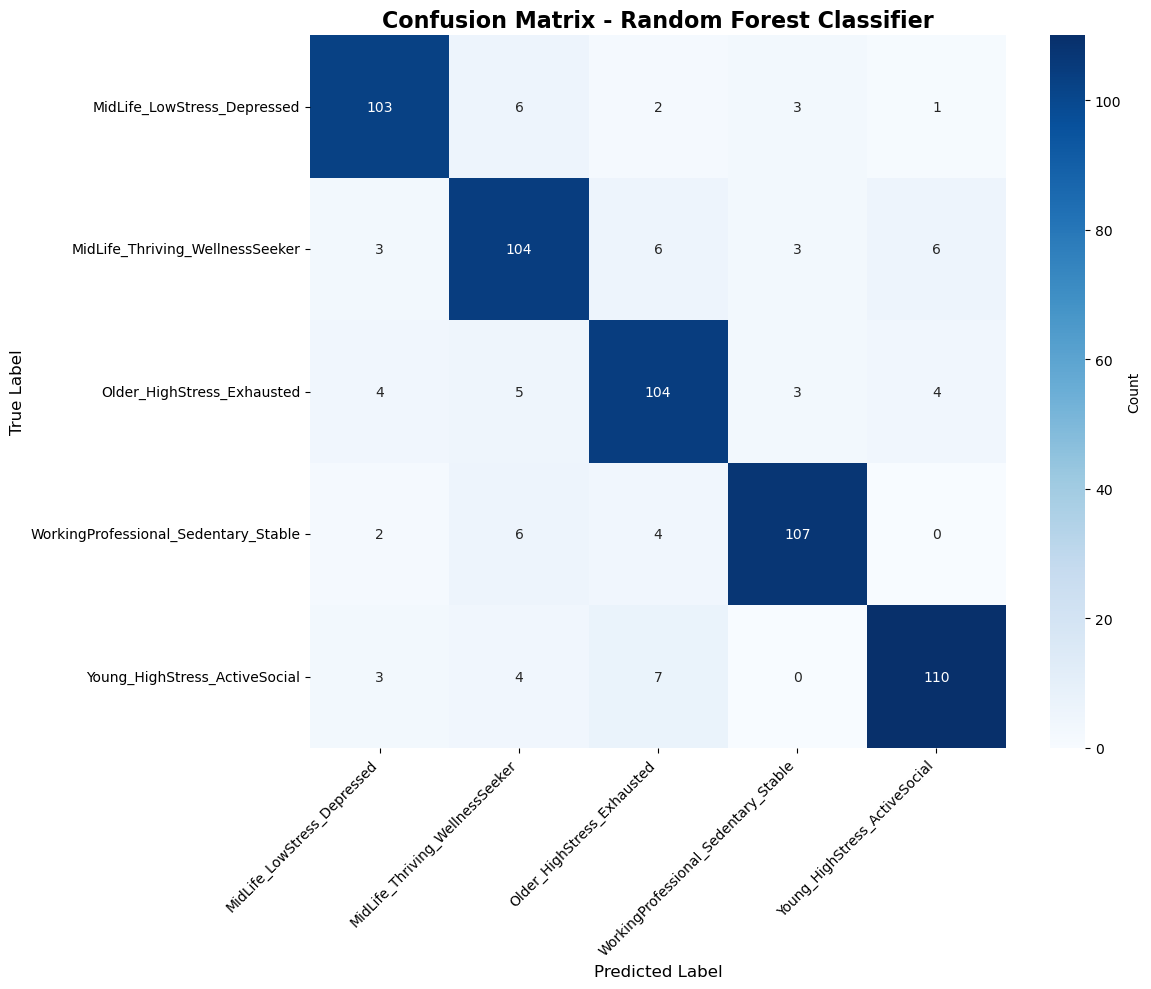


Confusion Matrix:
[[103   6   2   3   1]
 [  3 104   6   3   6]
 [  4   5 104   3   4]
 [  2   6   4 107   0]
 [  3   4   7   0 110]]


In [13]:
# Confusion Matrix Visualization
import seaborn as sns
cm = confusion_matrix(y_test, y_pred_test)
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Random Forest Classifier', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nConfusion Matrix:")
print(cm)

## Hyperparameter Tuning with Grid Search

Perform minimalistic grid search to find optimal Random Forest hyperparameters.

In [14]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid (minimalistic but effective)
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Initialize base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search with 3-fold CV
print("Starting Grid Search...")
print(f"Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf'])} combinations")

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "="*80)
print("GRID SEARCH RESULTS")
print("="*80)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print("="*80)

Starting Grid Search...
Testing 81 combinations
Fitting 3 folds for each of 81 candidates, totalling 243 fits

GRID SEARCH RESULTS
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
Best CV Score: 0.8737


Computing learning curves (this may take a moment)...
✓ Learning curves saved as 'learning_curves.png' (300 DPI)


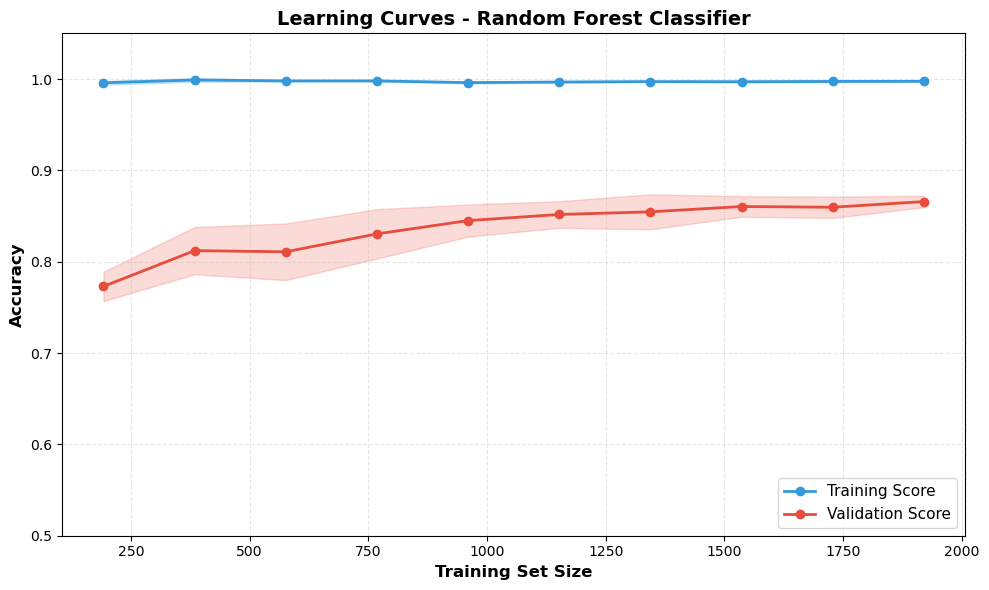


Learning Curve Analysis:
Final Training Score: 0.9975 (±0.0008)
Final Validation Score: 0.8658 (±0.0063)
Gap (overfitting indicator): 0.1317


In [11]:
# Learning Curves
from sklearn.model_selection import learning_curve

print("Computing learning curves (this may take a moment)...")

train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='#3498db')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='#e74c3c')

ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Learning Curves - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()

# Save the learning curves as high-quality image
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
print("✓ Learning curves saved as 'learning_curves.png' (300 DPI)")

plt.show()

print("\nLearning Curve Analysis:")
print(f"Final Training Score: {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"Final Validation Score: {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")
print(f"Gap (overfitting indicator): {(train_mean[-1] - val_mean[-1]):.4f}")

In [15]:
# Train final model with best parameters
best_rf_model = grid_search.best_estimator_

# Make predictions with optimized model
y_pred_train_best = best_rf_model.predict(X_train)
y_pred_test_best = best_rf_model.predict(X_test)

# Calculate accuracies
train_accuracy_best = accuracy_score(y_train, y_pred_train_best)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)

print("OPTIMIZED MODEL PERFORMANCE:")
print("="*80)
print(f"Training Accuracy: {train_accuracy_best:.4f}")
print(f"Testing Accuracy: {test_accuracy_best:.4f}")
print(f"\nImprovement over baseline:")
print(f"  Training: {(train_accuracy_best - train_accuracy)*100:+.2f}%")
print(f"  Testing: {(test_accuracy_best - test_accuracy)*100:+.2f}%")
print("="*80)

OPTIMIZED MODEL PERFORMANCE:
Training Accuracy: 0.9992
Testing Accuracy: 0.8633

Improvement over baseline:
  Training: +0.08%
  Testing: -1.67%


## Visualizations for Report

Professional plots to include in project documentation.

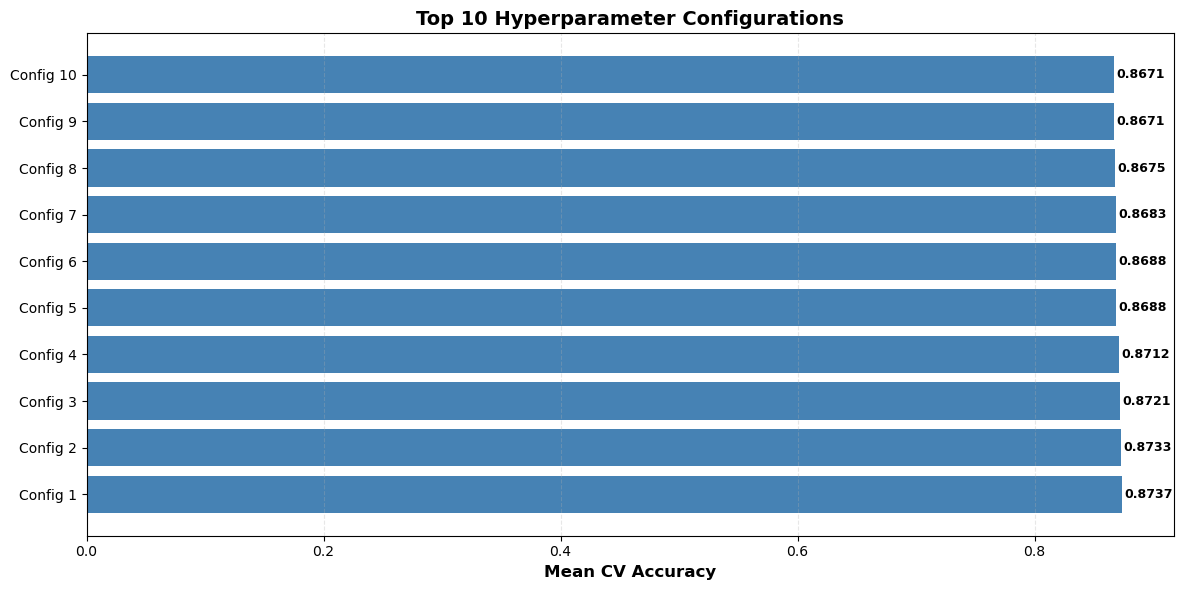


Top 3 Configurations:
1. Score: 0.8737 | n_est=150, max_d=10, min_split=2, min_leaf=1
2. Score: 0.8733 | n_est=150, max_d=15, min_split=2, min_leaf=1
3. Score: 0.8721 | n_est=100, max_d=10, min_split=2, min_leaf=1


In [16]:
# PLOT 1: Grid Search Results - Top 10 Configurations
results_df_grid = pd.DataFrame(grid_search.cv_results_)
results_df_grid = results_df_grid.sort_values('mean_test_score', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 6))
params_labels = [f"n={row['param_n_estimators']}, d={row['param_max_depth']}, "
                 f"split={row['param_min_samples_split']}, leaf={row['param_min_samples_leaf']}"
                 for _, row in results_df_grid.iterrows()]

bars = ax.barh(range(len(params_labels)), results_df_grid['mean_test_score'], color='steelblue')
ax.set_yticks(range(len(params_labels)))
ax.set_yticklabels([f"Config {i+1}" for i in range(len(params_labels))], fontsize=10)
ax.set_xlabel('Mean CV Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Hyperparameter Configurations', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, results_df_grid['mean_test_score'])):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{score:.4f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nTop 3 Configurations:")
for i, (idx, row) in enumerate(results_df_grid.head(3).iterrows(), 1):
    print(f"{i}. Score: {row['mean_test_score']:.4f} | "
          f"n_est={row['param_n_estimators']}, max_d={row['param_max_depth']}, "
          f"min_split={row['param_min_samples_split']}, min_leaf={row['param_min_samples_leaf']}")

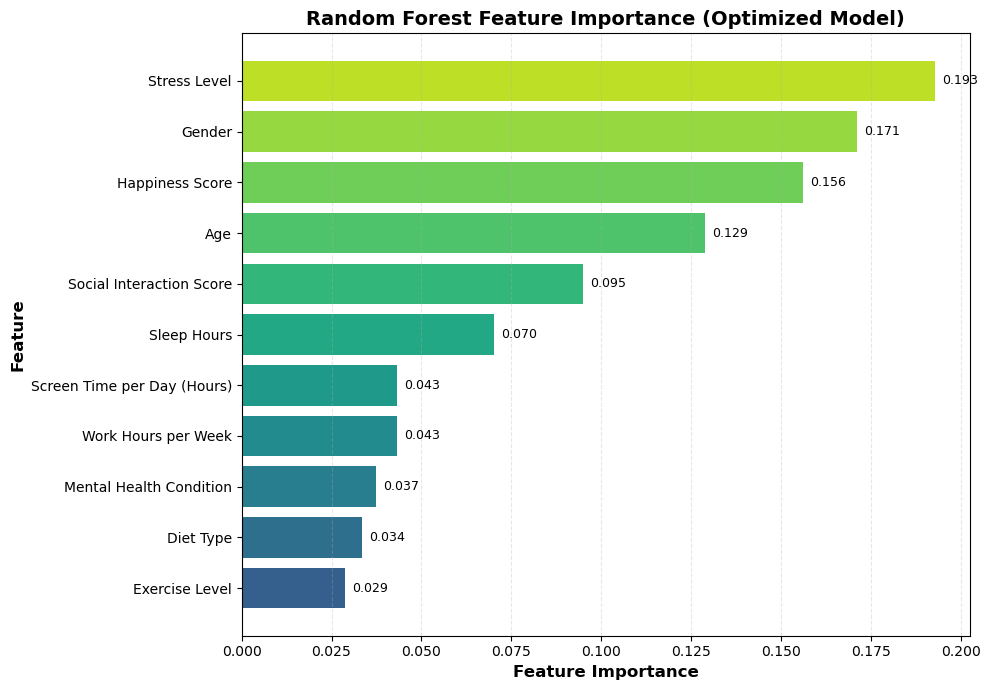


Feature Importance Ranking:
 1. Stress Level                   0.1928
 2. Gender                         0.1711
 3. Happiness Score                0.1560
 4. Age                            0.1289
 5. Social Interaction Score       0.0949
 6. Sleep Hours                    0.0702
 7. Screen Time per Day (Hours)    0.0432
 8. Work Hours per Week            0.0432
 9. Mental Health Condition        0.0373
10. Diet Type                      0.0335
11. Exercise Level                 0.0288


In [17]:
# PLOT 2: Feature Importance (Optimized Model)
feature_importance_best = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(feature_importance_best)))
bars = ax.barh(feature_importance_best['Feature'], feature_importance_best['Importance'], color=colors)
ax.set_xlabel('Feature Importance', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature', fontsize=12, fontweight='bold')
ax.set_title('Random Forest Feature Importance (Optimized Model)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for bar, importance in zip(bars, feature_importance_best['Importance']):
    ax.text(importance + 0.002, bar.get_y() + bar.get_height()/2, 
            f'{importance:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nFeature Importance Ranking:")
print("="*60)
for i, (_, row) in enumerate(feature_importance_best.sort_values('Importance', ascending=False).iterrows(), 1):
    print(f"{i:2d}. {row['Feature']:30s} {row['Importance']:.4f}")

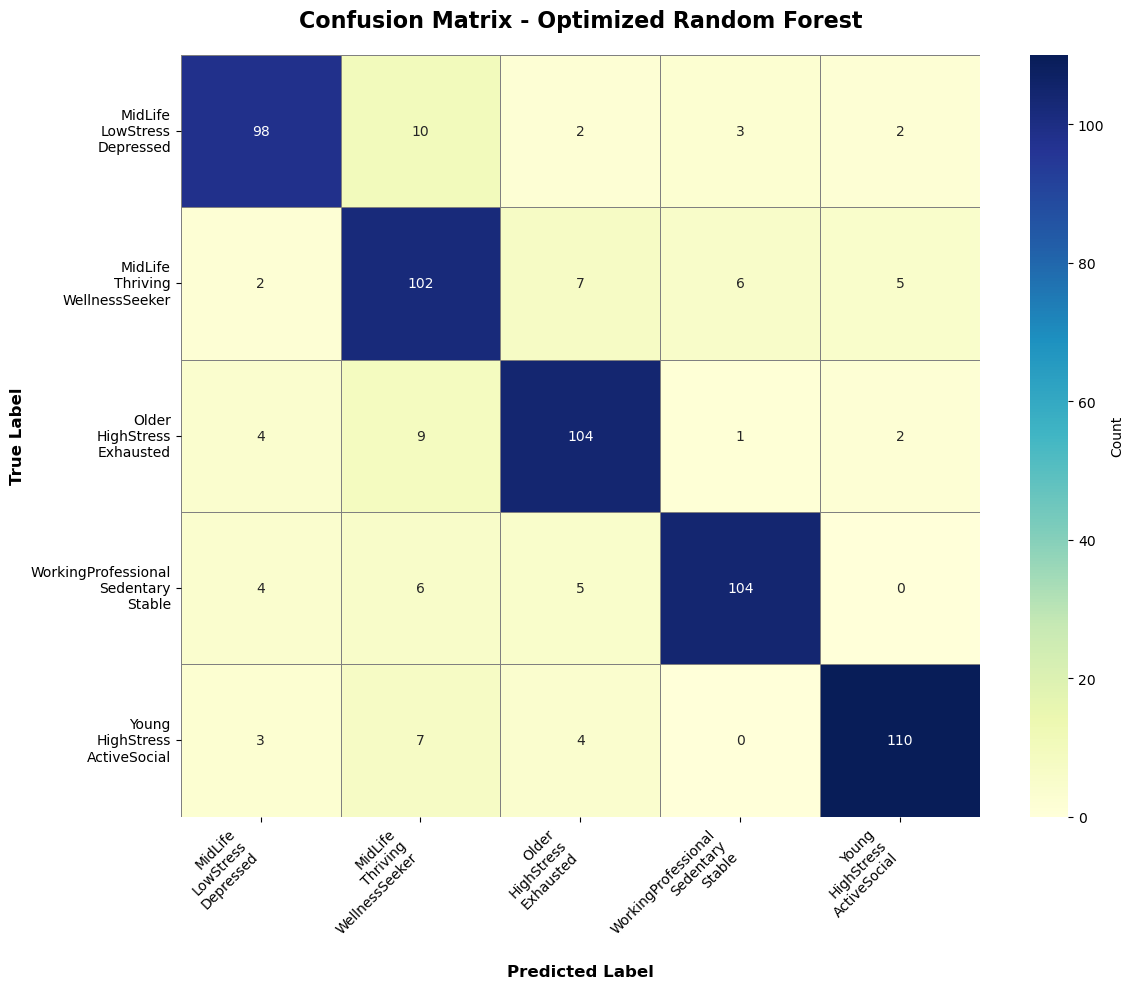


Per-Class Accuracy:
MidLife_LowStress_Depressed              85.22% (98/115)
MidLife_Thriving_WellnessSeeker          83.61% (102/122)
Older_HighStress_Exhausted               86.67% (104/120)
WorkingProfessional_Sedentary_Stable     87.39% (104/119)
Young_HighStress_ActiveSocial            88.71% (110/124)


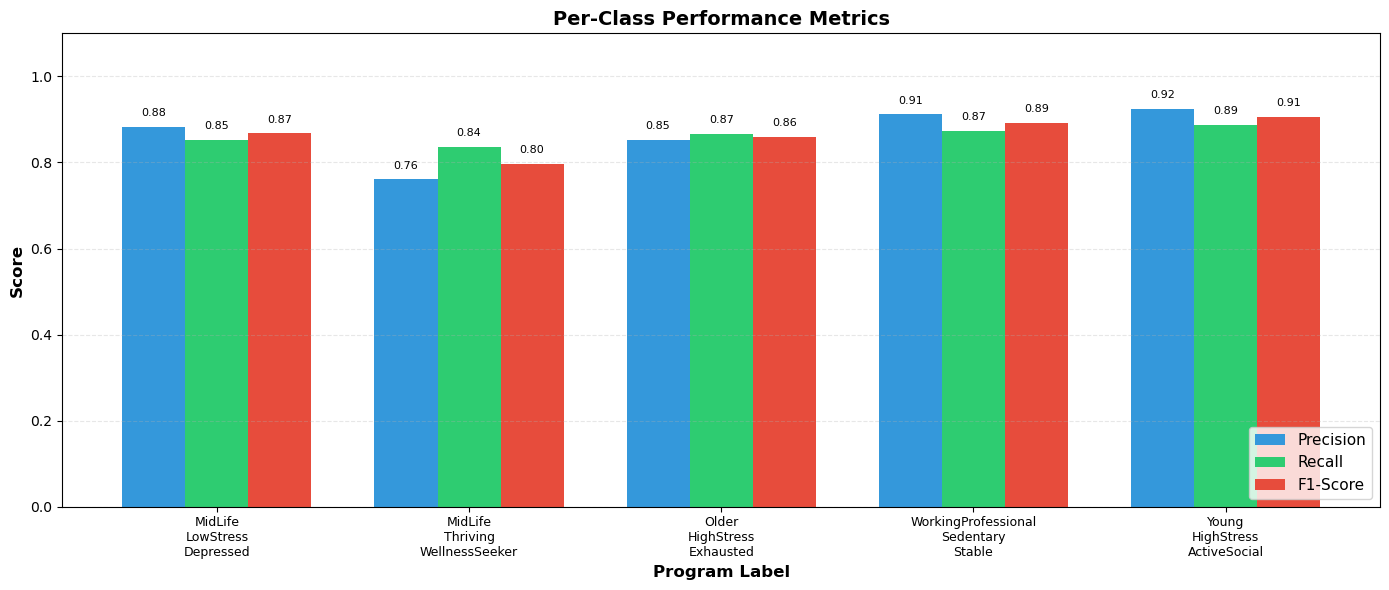


Detailed Metrics:
                               Class  Precision   Recall  F1-Score  Support
         MidLife_LowStress_Depressed   0.882883 0.852174  0.867257      115
     MidLife_Thriving_WellnessSeeker   0.761194 0.836066  0.796875      122
          Older_HighStress_Exhausted   0.852459 0.866667  0.859504      120
WorkingProfessional_Sedentary_Stable   0.912281 0.873950  0.892704      119
       Young_HighStress_ActiveSocial   0.924370 0.887097  0.905350      124


In [19]:
# PLOT 4: Per-Class Performance Metrics
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_test, y_pred_test_best, 
                                                                   labels=class_labels)

metrics_df = pd.DataFrame({
    'Class': class_labels,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(class_labels))
width = 0.25

bars1 = ax.bar(x - width, metrics_df['Precision'], width, label='Precision', color='#3498db')
bars2 = ax.bar(x, metrics_df['Recall'], width, label='Recall', color='#2ecc71')
bars3 = ax.bar(x + width, metrics_df['F1-Score'], width, label='F1-Score', color='#e74c3c')

ax.set_xlabel('Program Label', fontsize=12, fontweight='bold')
ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([label.replace('_', '\n') for label in class_labels], fontsize=9)
ax.legend(fontsize=11, loc='lower right')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print("\nDetailed Metrics:")
print(metrics_df.to_string(index=False))

In [ ]:
# PLOT 5: Model Comparison (Baseline vs Optimized)
comparison_data = {
    'Model': ['Baseline RF', 'Optimized RF'],
    'Training Accuracy': [train_accuracy, train_accuracy_best],
    'Testing Accuracy': [test_accuracy, test_accuracy_best],
    'CV Score': [cv_scores.mean(), grid_search.best_score_]
}

comparison_df = pd.DataFrame(comparison_data)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(comparison_df['Model']))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['Training Accuracy'], width, 
               label='Training Accuracy', color='#3498db', alpha=0.8)
bars2 = ax.bar(x, comparison_df['Testing Accuracy'], width, 
               label='Testing Accuracy', color='#2ecc71', alpha=0.8)
bars3 = ax.bar(x + width, comparison_df['CV Score'], width, 
               label='CV Score', color='#9b59b6', alpha=0.8)

ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Model'], fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0.5, 1.1)
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nModel Comparison Summary:")
print(comparison_df.to_string(index=False))

In [ ]:
# PLOT 6: Learning Curves
from sklearn.model_selection import learning_curve

print("Computing learning curves (this may take a moment)...")

train_sizes, train_scores, val_scores = learning_curve(
    best_rf_model, X_train, y_train,
    cv=3,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='#3498db')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='#e74c3c')

ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Learning Curves - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()

# Save the learning curves as high-quality image
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
print("✓ Learning curves saved as 'learning_curves.png' (300 DPI)")

plt.show()

print("\nLearning Curve Analysis:")
print(f"Final Training Score: {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"Final Validation Score: {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")
print(f"Gap (overfitting indicator): {(train_mean[-1] - val_mean[-1]):.4f}")

In [20]:
# Save the optimized model
optimized_model_filename = 'final_RF.pkl'
joblib.dump(best_rf_model, optimized_model_filename)
print(f"✓ Optimized model saved to '{optimized_model_filename}'")

# Save hyperparameters and results
optimization_results = {
    'best_params': grid_search.best_params_,
    'best_cv_score': grid_search.best_score_,
    'test_accuracy': test_accuracy_best,
    'feature_columns': feature_columns,
    'class_labels': class_labels,
    'feature_importance': dict(zip(feature_columns, best_rf_model.feature_importances_))
}
joblib.dump(optimization_results, 'rf_optimization_results.pkl')
print(f"✓ Optimization results saved to 'rf_optimization_results.pkl'")

✓ Optimized model saved to 'final_RF.pkl'
✓ Optimization results saved to 'rf_optimization_results.pkl'


## Summary: Report-Ready Visualizations

The following plots have been generated for your project report:

### **Plot 1: Grid Search Results**
- Shows top 10 hyperparameter configurations
- **Use in report**: Demonstrates systematic hyperparameter tuning methodology
- **Section**: Methodology → Model Optimization

### **Plot 2: Feature Importance**
- Ranks features by predictive power
- **Use in report**: Shows which user characteristics matter most for program assignment
- **Section**: Results → Feature Analysis

### **Plot 3: Confusion Matrix**
- Visualizes prediction accuracy per class
- **Use in report**: Demonstrates model's classification performance
- **Section**: Results → Model Evaluation

### **Plot 4: Per-Class Performance Metrics**
- Compares Precision, Recall, and F1-Score across all program labels
- **Use in report**: Detailed performance breakdown
- **Section**: Results → Classification Metrics

### **Plot 5: Model Comparison**
- Baseline vs Optimized model performance
- **Use in report**: Shows improvement from hyperparameter tuning
- **Section**: Results → Optimization Impact

### **Plot 6: Learning Curves**
- Training vs validation accuracy as training set size increases
- **Use in report**: Demonstrates model's learning behavior and generalization
- **Section**: Results → Model Validation

---

**Files Saved:**
- `random_forest_optimized.pkl` - Best performing model
- `rf_optimization_results.pkl` - Hyperparameters and metrics

**Recommended Report Structure:**
1. Data Preprocessing & Clustering (k=5 with silhouette score ≈ 0.45)
2. Random Forest Classifier Development
3. Hyperparameter Optimization (Grid Search)
4. Model Evaluation (6 visualizations above)
5. Feature Importance Analysis
6. Conclusions & Deployment Recommendations

Feature Importance:
                    Feature  Importance
               Stress Level    0.201831
                     Gender    0.174589
            Happiness Score    0.156635
                        Age    0.125620
   Social Interaction Score    0.093836
                Sleep Hours    0.068193
        Work Hours per Week    0.042390
Screen Time per Day (Hours)    0.039940
    Mental Health Condition    0.037011
                  Diet Type    0.031325
             Exercise Level    0.028630


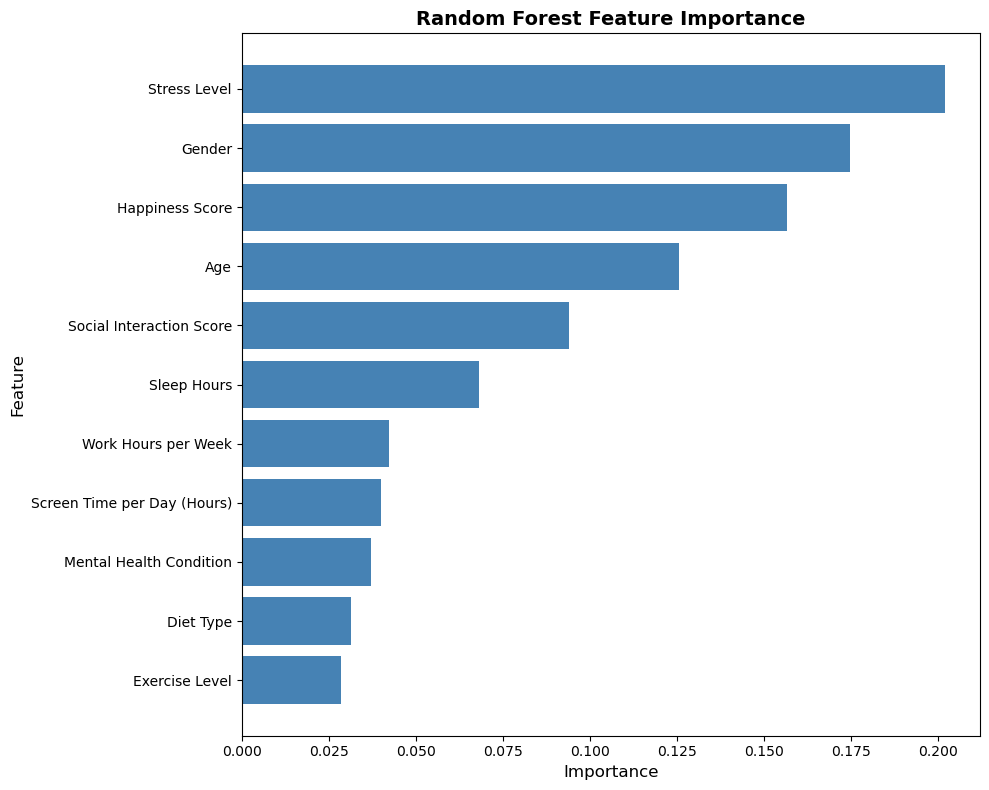

In [8]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance:")
print("="*50)
print(feature_importance.to_string(index=False))

# Visualize feature importance
plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [47]:
# Save the trained Random Forest model
model_filename = 'random_forest_program_classifier.pkl'
joblib.dump(rf_model, model_filename)
print(f"✓ Model saved to '{model_filename}'")

# Save feature column names for future use
feature_info = {
    'feature_columns': feature_columns,
    'class_labels': class_labels
}
joblib.dump(feature_info, 'rf_feature_info.pkl')
print(f"✓ Feature info saved to 'rf_feature_info.pkl'")

✓ Model saved to 'random_forest_program_classifier.pkl'
✓ Feature info saved to 'rf_feature_info.pkl'


In [9]:
# Example: How to use the model for new predictions
print("="*80)
print("EXAMPLE: Predicting Program Label for New Users")
print("="*80)

# Take a few examples from test set
sample_users = X_test.head(5)
sample_true_labels = y_test.head(5).values
sample_predictions = rf_model.predict(sample_users)
sample_probabilities = rf_model.predict_proba(sample_users)

for i in range(len(sample_users)):
    print(f"\nUser {i+1}:")
    print(f"  Features: {sample_users.iloc[i].to_dict()}")
    print(f"  True Label: {sample_true_labels[i]}")
    print(f"  Predicted Label: {sample_predictions[i]}")
    print(f"  Prediction Confidence: {max(sample_probabilities[i]):.2%}")
    print(f"  Match: {'✓' if sample_true_labels[i] == sample_predictions[i] else '✗'}")

EXAMPLE: Predicting Program Label for New Users

User 1:
  Features: {'Age': 27.0, 'Gender': 0.0, 'Exercise Level': 2.0, 'Diet Type': 1.0, 'Sleep Hours': 5.4, 'Stress Level': 0.0, 'Mental Health Condition': 3.0, 'Work Hours per Week': 37.0, 'Screen Time per Day (Hours)': 7.7, 'Social Interaction Score': 8.2, 'Happiness Score': 6.0}
  True Label: WorkingProfessional_Sedentary_Stable
  Predicted Label: WorkingProfessional_Sedentary_Stable
  Prediction Confidence: 84.40%
  Match: ✓

User 2:
  Features: {'Age': 49.0, 'Gender': 0.0, 'Exercise Level': 0.0, 'Diet Type': 1.0, 'Sleep Hours': 6.5, 'Stress Level': 0.0, 'Mental Health Condition': 1.0, 'Work Hours per Week': 53.0, 'Screen Time per Day (Hours)': 4.6, 'Social Interaction Score': 5.2, 'Happiness Score': 4.2}
  True Label: WorkingProfessional_Sedentary_Stable
  Predicted Label: WorkingProfessional_Sedentary_Stable
  Prediction Confidence: 75.98%
  Match: ✓

User 3:
  Features: {'Age': 40.0, 'Gender': 2.0, 'Exercise Level': 2.0, 'Diet T

Computing learning curves (this may take a moment)...
✓ Learning curves saved as 'learning_curves.png' (300 DPI)


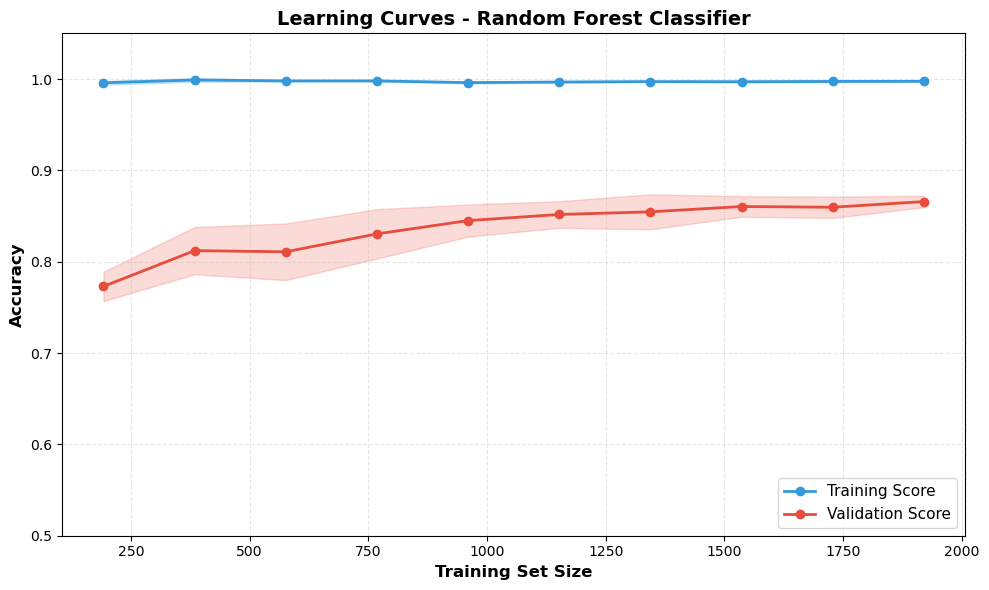


Learning Curve Analysis:
Final Training Score: 0.9975 (±0.0008)
Final Validation Score: 0.8658 (±0.0063)
Gap (overfitting indicator): 0.1317


In [12]:
# Learning Curves
from sklearn.model_selection import learning_curve

print("Computing learning curves (this may take a moment)...")

train_sizes, train_scores, val_scores = learning_curve(
    rf_model, X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, 'o-', color='#3498db', label='Training Score', linewidth=2)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.2, color='#3498db')

ax.plot(train_sizes, val_mean, 'o-', color='#e74c3c', label='Validation Score', linewidth=2)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.2, color='#e74c3c')

ax.set_xlabel('Training Set Size', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Learning Curves - Random Forest Classifier', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3, linestyle='--')
ax.set_ylim(0.5, 1.05)

plt.tight_layout()

# Save the learning curves as high-quality image
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
print("✓ Learning curves saved as 'learning_curves.png' (300 DPI)")

plt.show()

print("\nLearning Curve Analysis:")
print(f"Final Training Score: {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"Final Validation Score: {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")
print(f"Gap (overfitting indicator): {(train_mean[-1] - val_mean[-1]):.4f}")

STEP 1: GRID SEARCH FOR OPTIMAL HYPERPARAMETERS
Testing 81 combinations...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

✓ Best Parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}
✓ Best CV Score: 0.8737
✓ Test Accuracy: 0.8633

STEP 2: GENERATING LEARNING CURVES
Computing learning curves (this may take a few minutes)...
[learning_curve] Training set sizes: [ 192  384  576  768  960 1152 1344 1536 1728 1920]


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    3.7s finished



✓ Learning curves saved as 'learning_curves_optimized.png' (300 DPI)


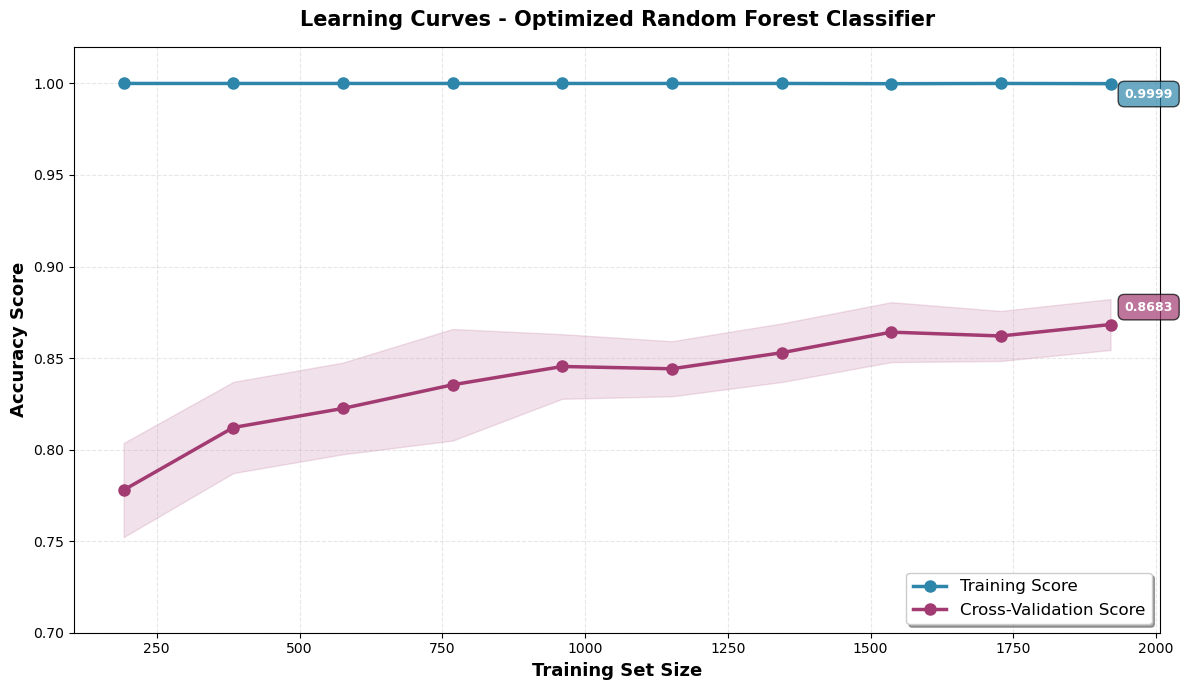


LEARNING CURVE ANALYSIS
Training Set Sizes: [ 192  384  576  768  960 1152 1344 1536 1728 1920]

Final Training Score:      0.9999 (±0.0002)
Final Validation Score:    0.8683 (±0.0139)
Overfitting Gap:           0.1316
Model Generalization:      Poor

Learning Progression:
------------------------------------------------------------
Size       Train Acc    Val Acc      Gap       
------------------------------------------------------------
192        1.0000       0.7779       0.2221
384        1.0000       0.8121       0.1879
576        1.0000       0.8225       0.1775
768        1.0000       0.8354       0.1646
960        1.0000       0.8454       0.1546
1152       1.0000       0.8442       0.1558
1344       1.0000       0.8529       0.1471
1536       0.9999       0.8642       0.1357
1728       1.0000       0.8621       0.1379
1920       0.9999       0.8683       0.1316

STEP 3: SAVING FINAL MODEL
✓ Optimized model saved to 'final_RF.pkl'
✓ Optimization results saved to 'rf_optimizat

In [ ]:
# COMPLETE RETRAINING AND LEARNING CURVE GENERATION WITH REGULARIZATION
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import accuracy_score
import joblib

print("="*80)
print("STEP 1: GRID SEARCH WITH REGULARIZATION TO PREVENT OVERFITTING")
print("="*80)

# Define parameter grid with REGULARIZATION
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 7, 10],  # Reduced from [10, 15, 20] to prevent overfitting
    'min_samples_split': [10, 20, 30],  # Increased from [2, 5, 10]
    'min_samples_leaf': [5, 10, 15],  # Increased from [1, 2, 4]
    'max_features': ['sqrt', 'log2'],  # CRITICAL: prevents using all features
    'min_impurity_decrease': [0.0, 0.001, 0.01]  # Requires minimum improvement to split
}

# Initialize base model
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search with 5-fold CV (increased from 3 for better validation)
print(f"Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split']) * len(param_grid['min_samples_leaf']) * len(param_grid['max_features']) * len(param_grid['min_impurity_decrease'])} combinations...")
print("This will take a few minutes with regularization parameters...")

grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,  # Increased from 3
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\n✓ Best Parameters: {grid_search.best_params_}")
print(f"✓ Best CV Score: {grid_search.best_score_:.4f}")

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate on test set
y_pred_train_best = best_rf_model.predict(X_train)
y_pred_test_best = best_rf_model.predict(X_test)
train_accuracy_best = accuracy_score(y_train, y_pred_train_best)
test_accuracy_best = accuracy_score(y_test, y_pred_test_best)

print(f"✓ Train Accuracy: {train_accuracy_best:.4f}")
print(f"✓ Test Accuracy: {test_accuracy_best:.4f}")
print(f"✓ Overfitting Gap: {(train_accuracy_best - test_accuracy_best):.4f}")

print("\n" + "="*80)
print("STEP 2: GENERATING LEARNING CURVES")
print("="*80)

# Create a FRESH unfitted estimator with best parameters for learning curve
fresh_rf_model = RandomForestClassifier(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

print("Computing learning curves (this may take a few minutes)...")

# Compute learning curves with the UNFITTED model
train_sizes, train_scores, val_scores = learning_curve(
    fresh_rf_model,
    X_train, y_train,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Create professional plot
fig, ax = plt.subplots(figsize=(12, 7))

# Plot training score
ax.plot(train_sizes, train_mean, 'o-', color='#2E86AB', label='Training Score', 
        linewidth=2.5, markersize=8)
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, 
                 alpha=0.15, color='#2E86AB')

# Plot validation score
ax.plot(train_sizes, val_mean, 'o-', color='#A23B72', label='Cross-Validation Score', 
        linewidth=2.5, markersize=8)
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, 
                 alpha=0.15, color='#A23B72')

ax.set_xlabel('Training Set Size', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=13, fontweight='bold')
ax.set_title('Learning Curves - Regularized Random Forest Classifier', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=12, frameon=True, shadow=True)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.set_ylim(0.70, 1.02)

# Add value annotations for final points
ax.annotate(f'{train_mean[-1]:.4f}', 
            xy=(train_sizes[-1], train_mean[-1]), 
            xytext=(10, -10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='#2E86AB', alpha=0.7),
            color='white', fontweight='bold', fontsize=9)

ax.annotate(f'{val_mean[-1]:.4f}', 
            xy=(train_sizes[-1], val_mean[-1]), 
            xytext=(10, 10), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='#A23B72', alpha=0.7),
            color='white', fontweight='bold', fontsize=9)

plt.tight_layout()

# Save as high-quality image
plt.savefig('learning_curves_optimized.png', dpi=300, bbox_inches='tight', facecolor='white')
print("\n✓ Learning curves saved as 'learning_curves_optimized.png' (300 DPI)")

plt.show()

print("\n" + "="*80)
print("LEARNING CURVE ANALYSIS")
print("="*80)
print(f"Training Set Sizes: {train_sizes.astype(int)}")
print(f"\nFinal Training Score:      {train_mean[-1]:.4f} (±{train_std[-1]:.4f})")
print(f"Final Validation Score:    {val_mean[-1]:.4f} (±{val_std[-1]:.4f})")
print(f"Overfitting Gap:           {(train_mean[-1] - val_mean[-1]):.4f}")

gap = train_mean[-1] - val_mean[-1]
if gap < 0.05:
    generalization = "Excellent"
elif gap < 0.08:
    generalization = "Good"
elif gap < 0.12:
    generalization = "Moderate"
else:
    generalization = "Poor (Overfitting)"

print(f"Model Generalization:      {generalization}")

# Show learning progression
print("\nLearning Progression:")
print("-" * 60)
print(f"{'Size':<10} {'Train Acc':<12} {'Val Acc':<12} {'Gap':<10}")
print("-" * 60)
for i in range(len(train_sizes)):
    gap = train_mean[i] - val_mean[i]
    print(f"{int(train_sizes[i]):<10} {train_mean[i]:.4f}       {val_mean[i]:.4f}       {gap:.4f}")

print("\n" + "="*80)
print("STEP 3: SAVING FINAL MODEL")
print("="*80)

# Save the optimized model
joblib.dump(best_rf_model, 'final_RF.pkl')
print("✓ Optimized model saved to 'final_RF.pkl'")

# Save optimization results
optimization_results = {
    'best_params': grid_search.best_params_,
    'best_cv_score': grid_search.best_score_,
    'test_accuracy': test_accuracy_best,
    'train_accuracy': train_accuracy_best,
    'overfitting_gap': train_accuracy_best - test_accuracy_best,
    'feature_columns': feature_columns,
    'class_labels': class_labels.tolist() if hasattr(class_labels, 'tolist') else list(class_labels),
    'feature_importance': dict(zip(feature_columns, best_rf_model.feature_importances_))
}
joblib.dump(optimization_results, 'rf_optimization_results.pkl')
print("✓ Optimization results saved to 'rf_optimization_results.pkl'")

print("\n" + "="*80)
print("REGULARIZATION SUMMARY")
print("="*80)
print("Applied Regularization Techniques:")
print("  • max_features: Limits features per split (prevents overfitting)")
print("  • Increased min_samples_leaf: Requires more samples in leaf nodes")
print("  • Increased min_samples_split: Requires more samples to split")
print("  • Reduced max_depth: Limits tree complexity")
print("  • min_impurity_decrease: Requires minimum improvement to split")
print("\n" + "="*80)
print("COMPLETE!")
print("="*80)